In [1]:
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

import matplotlib.pyplot as plt
import seaborn as sns

print("TensorFlow Version :", tf.__version__)

TensorFlow Version : 2.20.0


In [2]:
!mkdir -p /root/.kaggle
!cp "/content/drive/MyDrive/kaggle.json" /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

cp: cannot stat '/content/drive/MyDrive/kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [3]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:00<00:00, 190MB/s]



In [4]:
!unzip brain-tumor-mri-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: Training/glioma/Tr-gl_279.jpg  
  inflating: Training/glioma/Tr-gl_28.jpg  
  inflating: Training/glioma/Tr-gl_280.jpg  
  inflating: Training/glioma/Tr-gl_281.jpg  
  inflating: Training/glioma/Tr-gl_282.jpg  
  inflating: Training/glioma/Tr-gl_283.jpg  
  inflating: Training/glioma/Tr-gl_284.jpg  
  inflating: Training/glioma/Tr-gl_285.jpg  
  inflating: Training/glioma/Tr-gl_286.jpg  
  inflating: Training/glioma/Tr-gl_287.jpg  
  inflating: Training/glioma/Tr-gl_288.jpg  
  inflating: Training/glioma/Tr-gl_289.jpg  
  inflating: Training/glioma/Tr-gl_29.jpg  
  inflating: Training/glioma/Tr-gl_290.jpg  
  inflating: Training/glioma/Tr-gl_291.jpg  
  inflating: Training/glioma/Tr-gl_292.jpg  
  inflating: Training/glioma/Tr-gl_293.jpg  
  inflating: Training/glioma/Tr-gl_294.jpg  
  inflating: Training/glioma/Tr-gl_295.jpg  
  inflating: Training/glioma/Tr-gl_296.jpg  
  inflating: Training/glioma/Tr-gl_297.jpg  
  infl

In [5]:
train_ds=tf.keras.preprocessing.image_dataset_from_directory("/content/Testing",validation_split=0.2,subset='training',seed=42, image_size=(128,128),batch_size=32)
val_ds=tf.keras.preprocessing.image_dataset_from_directory("/content/Training",validation_split=0.2,subset='training',seed=42, image_size=(128,128),batch_size=32)

Found 1600 files belonging to 4 classes.
Using 1280 files for training.
Found 5600 files belonging to 4 classes.
Using 4480 files for training.


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, Flatten, Dropout, MaxPooling2D

In [7]:
normalization_layers = tf.keras.layers.Rescaling(1./255)

train_data = train_ds.map(lambda x, y : (normalization_layers(x), y))
val_data =val_ds.map(lambda x, y : (normalization_layers(x), y))

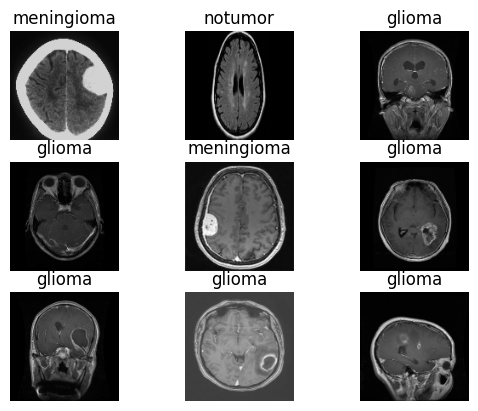

In [8]:
import matplotlib.pyplot as plt

class_names = train_ds.class_names

for images, labels in train_data.take(1):
  for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i])
    plt.title(class_names[labels[i]])
    plt.axis("off")

plt.show()

In [9]:
from keras.src.layers import Conv2D
from keras.src.layers.pooling.max_pooling2d import MaxPooling2D
from keras.src.models.sequential import Sequential
model = Sequential()

model.add(Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same', input_shape=(128, 128, 3)))
model.add(MaxPooling2D())

model.add(Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same'))
model.add(MaxPooling2D())

model.add(Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same'))
model.add(MaxPooling2D())

model.add(Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same'))
model.add(MaxPooling2D())

model.add(Flatten())
model.add(Dense(512, activation = 'relu'))
model.add(Dropout(0.5))

model.add(Dense(len(class_names), activation='softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.compile(
    loss = 'sparse_categorical_crossentropy',
    optimizer = 'adam',
    metrics = ['accuracy']
)

In [11]:
model.fit(
    train_data,
    validation_data = (val_ds),
    verbose = 1,
    epochs = 10
)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 294ms/step - accuracy: 0.4219 - loss: 2.2375 - val_accuracy: 0.5455 - val_loss: 49.9170
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 137ms/step - accuracy: 0.6406 - loss: 0.8474 - val_accuracy: 0.6033 - val_loss: 84.4277
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 153ms/step - accuracy: 0.7180 - loss: 0.6536 - val_accuracy: 0.7013 - val_loss: 74.3563
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 160ms/step - accuracy: 0.7797 - loss: 0.5354 - val_accuracy: 0.6634 - val_loss: 129.2859
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 155ms/step - accuracy: 0.8352 - loss: 0.4036 - val_accuracy: 0.6993 - val_loss: 118.5283
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 158ms/step - accuracy: 0.8695 - loss: 0.3475 - val_accuracy: 0.6973 - val_loss: 155.8871
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 128ms/step - accuracy: 0.8453 - loss: 0.3357 - val_accuracy: 0.6665 - val_loss: 171.5979
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 158ms/step - accuracy: 0.9086 - loss: 0.2376 - val

In [13]:
import numpy as np
from tensorflow.keras.preprocessing import image

img_path = '/content/Testing/glioma/Te-gl_104.jpg'
img = image.load_img(img_path, target_size = (128, 128))

img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis = 0)

predicstions = model.predict(img_array)

predicted_class_idx = np.argmax(predicstions[0])

predicted_class_name = class_names[predicted_class_idx]

print(f"Predicted Class : {predicted_class_name}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 895ms/step
Predicted Class : glioma


In [14]:
model.save('CNN__Brain Tumor MRI.h5')